# Time-Frequency Analysis

### Import all the necessary functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
#-----imports-----#
import numpy as np
from matplotlib import pyplot as plt
import mne

from mne import Epochs, create_info
from mne.io import RawArray
from mne.time_frequency import AverageTFRArray, EpochsTFRArray, tfr_array_morlet

import os
import matplotlib.pyplot as plt

In [3]:
import sys 
from pathlib import Path

# get project root 
project_root = Path("/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis")
sys.path.append(str(project_root))



In [14]:
from _02_Movidoc_tictrack_prepro_TTL_extraction_patients import (
    load_data,
    extract_stimuli,
    preprocess_data, 
    apply_ICA, 
    apply_rest_reference,
    recalibrate_from_first_event,
    collect_ttl_with_phases
)

>>> LE SCRIPT A BIEN ÉTÉ LANCÉ


In [5]:
from _03_Movidoc_tictrack_tic_extraction_patients import extract_tics_from_excel

In [6]:
from _04_Movidoc_full_pipeline_analysis_patients import (
    assign_phase_to_tics,
    extract_eeg_phase_times_from_ttl,
    realign_excel_to_eeg,
    build_merged_ttl_tics,
    run_full_pipeline_for_patient,
    shift_urges_times,
    extract_random_epochs_in_phase,
    analyse_merged_ttl_tics_spontaneous,
    extract_pre_tic_epochs,
    full_pipeline_extract_pre_tic_epochs,
)

>>> LE SCRIPT A BIEN ÉTÉ LANCÉ


In [7]:
from _05_Movidoc_tictrack_urge_extraction_function import (
    deduplicate_imitated_tics,
    analyse_merged_ttl_tics_imitated,
    deduplicate_suppressed_tics,
    analyse_merged_ttl_tics_suppressed,
)

In [8]:
from _06_Movidoc_tictrack_TFR_functions import (
    trf_analysis_normalized,
    tfr_per_ROI_normalized,
    plot_trf_roi
)



### Load data

In [9]:
# Base directory for this project
base_dir = "/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis"
patient_files_dir = os.path.join(base_dir, "PATIENT FILES")
eeg_dir = os.path.join(patient_files_dir, "EEG PATIENT FILES")
excel_dir = os.path.join(patient_files_dir, "EXCEL PATIENT FILES")



In [10]:
# Define patient configurations
patients = [
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000010.vhdr"),
        "excel": os.path.join(excel_dir, "DS26_annotations_binary-table_cutted.xlsx"), # DS26
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [13.728, 50.028, 190.080, 349.272, 980.727, 1277.991]
    },
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack_BB28-bis.vhdr"), #BB28
        "excel": os.path.join(excel_dir, "BB28_annotations_binary-table_cutted.xlsx"),
        "fps": 25,
        "min_absence_frames": 25,
        "excel_phase_times": [9.840, 27.320, 156.880, 302.600, 929.960, 991.760]
    },
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000013.vhdr"), # BC29
        "excel": os.path.join(excel_dir, "BC29_annotations_binary-table_cutted_Lizbeth.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [17.391, 65.670, 201.597, 358.215, 1088.670, 1204.038]
    },
    {
        "montage": "standard_1005", # montage with 64 electrodes (from MM30 : always 64 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000030.vhdr"), # MM30
        "excel": os.path.join(excel_dir, "MM30_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [6.633, 68.277, 196.581, 323.994, 931.194, 995.049]
    },
    {
        "montage": "standard_1005", # montage with 64 electrodes (from MM30 : always 64 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000031.vhdr"), # SC31
        "excel": os.path.join(excel_dir, "SC31_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [12.243, 62.040, 191.664, 345.972, 970.200, 1074.546]
    }
]

## Run full pipeline - Epoch extraction


===== START Patient /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr =====

--- Traitement du fichier : _BB28-bis ---

Extracting parameters from /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr...
Setting channel info structure...
Reading 0 ... 841719  =      0.000 ...  1683.438 secs...


/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_02_Movidoc_tictrack_prepro_TTL_extraction_patients.py:69: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(FilePath, preload=True)


['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
None
Subject name: _BB28-bis
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 16501 samples (33.002 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Filtering raw data in 1 contiguous segment


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    0.9s finished


Removed notch frequencies (Hz):
     50.00 : 10168 windows
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 205 events and 5000 original time points ...
0 bad epochs dropped


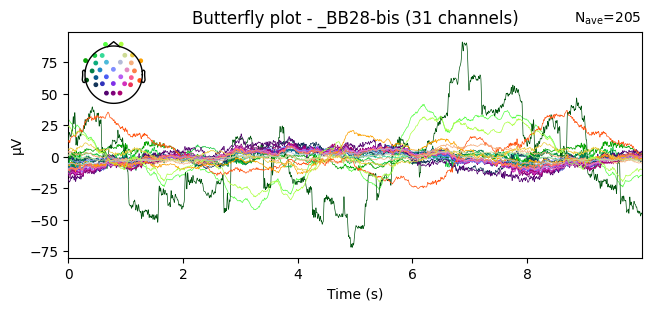

Spiky channel: FT10, max amplitude: 14808.1 µV


  0%|          | interpolating channels : 0/50 [00:00<?,       ?it/s]

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


  0%|          | Iterating epochs : 0/205 [00:00<?,       ?it/s]

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   34.8s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   34.8s finished


[Done]
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.0 mm
Computing interpolation matrix from 30 sensor positions
Interpolating 1 sensors
Ransac detected bad channels: ['TP9']
Bad channels marked for _BB28-bis : ['TP9', 'Fp1']
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 205 events and 5000 original time points ...
0 bad epochs dropped


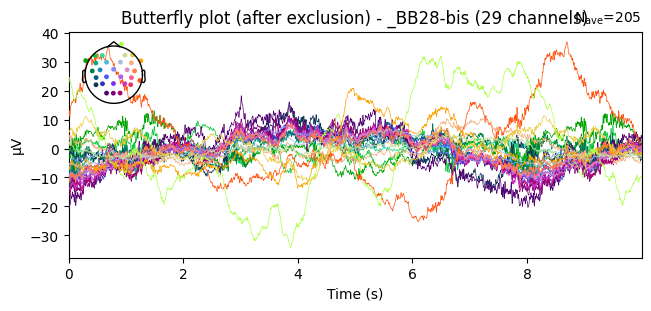

Fp1: 6174.4 µV
F3: 705.9 µV
F7: 1236.8 µV
FT9: 648.2 µV
FC5: 1017.5 µV
FC1: 479.4 µV
C3: 616.3 µV
T7: 1316.1 µV
TP9: 6535.4 µV
CP5: 765.1 µV
CP1: 534.7 µV
Pz: 553.5 µV
P3: 566.6 µV
P7: 3725.0 µV
O1: 942.9 µV
Oz: 1217.8 µV
O2: 855.8 µV
P4: 589.7 µV
P8: 598.6 µV
TP10: 6210.6 µV
CP6: 599.4 µV
CP2: 534.9 µV
Cz: 538.6 µV
C4: 532.7 µV
T8: 667.7 µV
FT10: 14808.1 µV
FC6: 2386.0 µV
FC2: 454.6 µV
F4: 446.5 µV
F8: 1141.9 µV
Fp2: 6642.6 µV
Not setting metadata
823 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 823 events and 1001 original time points ...
0 bad epochs dropped
Estimating rejection dictionary for eeg
    Rejecting  epoch based on EEG : ['FT10']
    Rejecting  epoch based on EEG : ['FT9', 'TP10']
    Rejecting  epoch based on EEG : ['F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'Pz', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'T8', 'FT10', 'F8', 'Fp2']
    Rejecting  epoch based on EEG : ['F7', 'T7', 'O

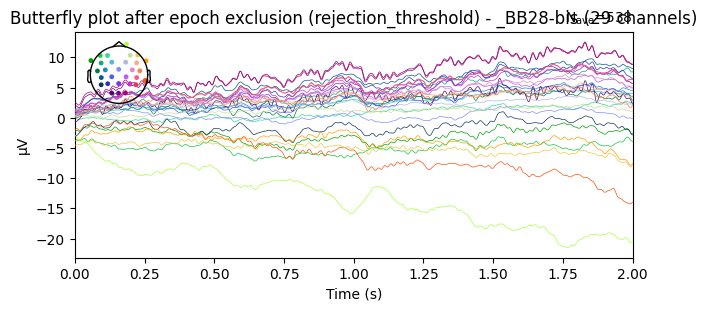

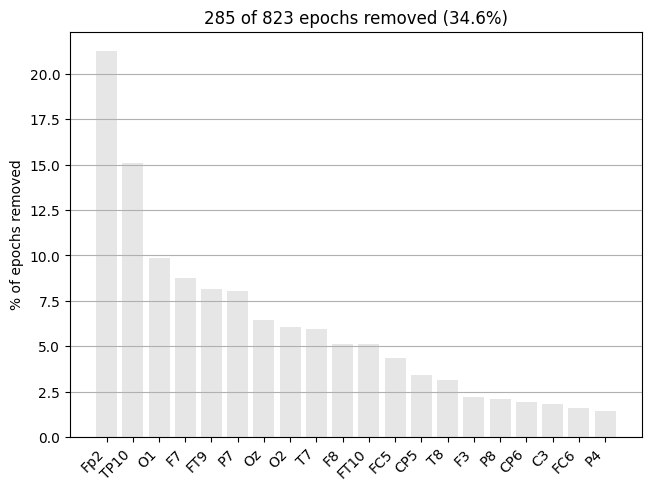

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 29 channels (please be patient, this may take a while)


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    0.7s finished


Selecting by number: 10 components
Fitting ICA took 32.2s.


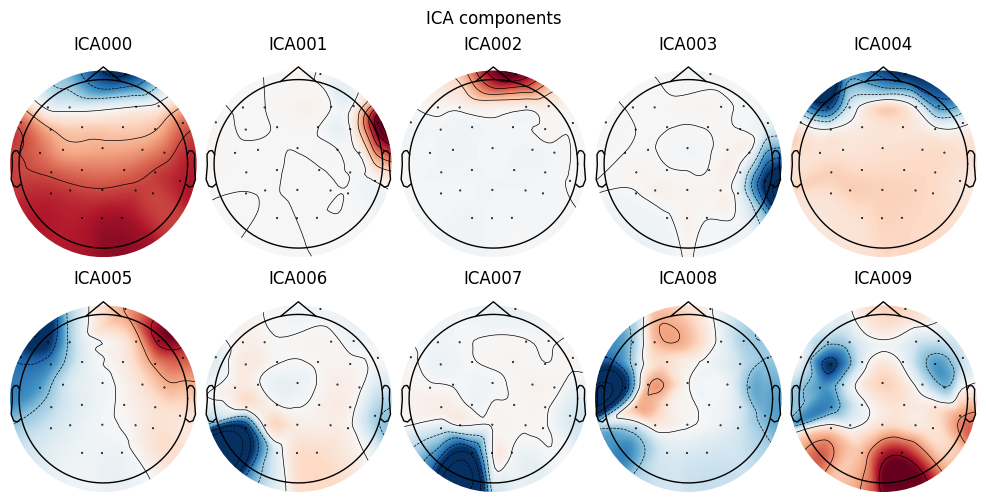

Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 82 events and 10000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items a

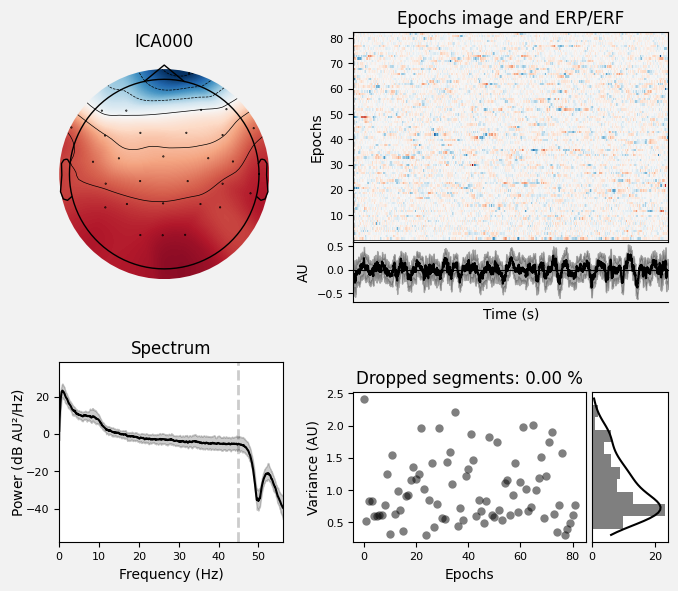

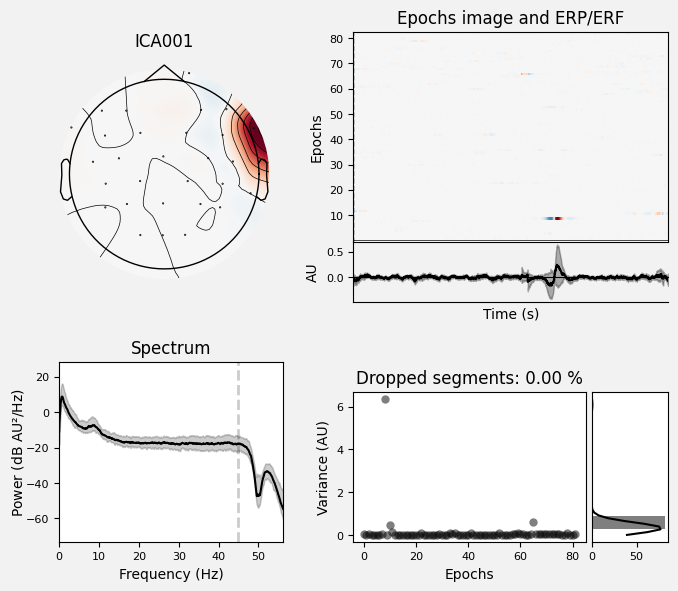

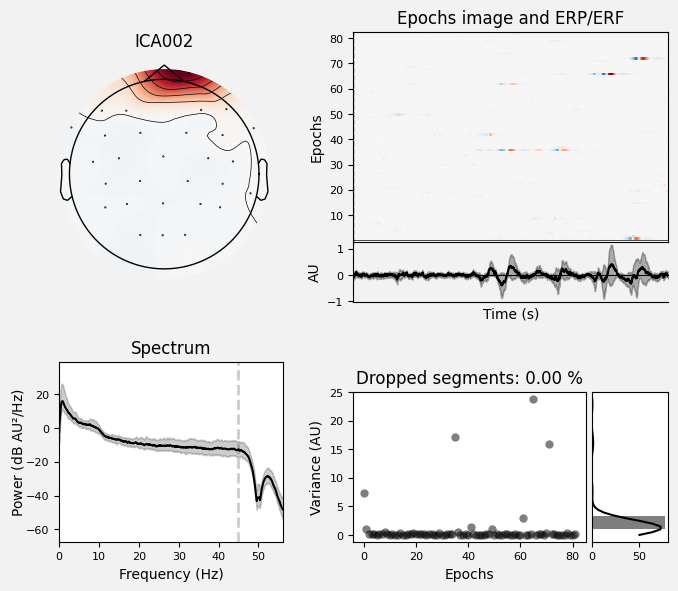

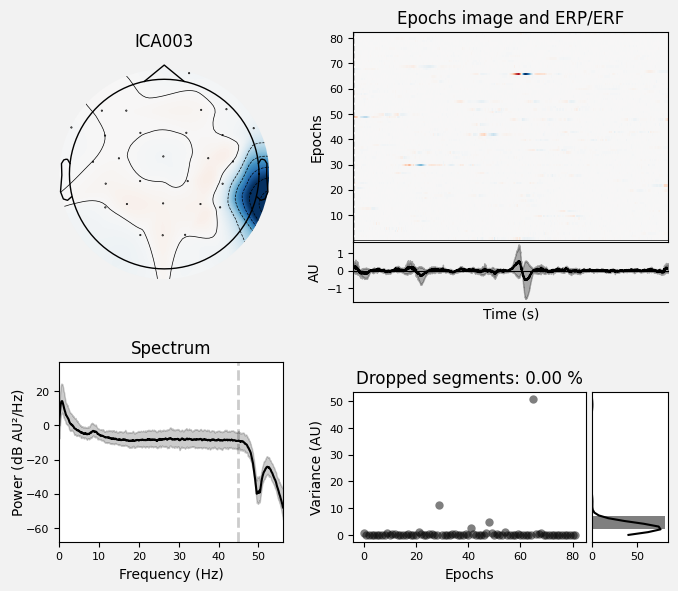

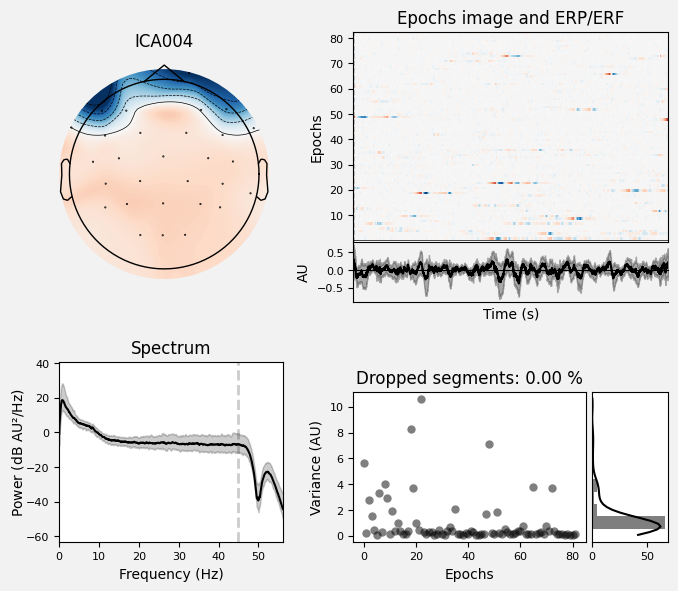

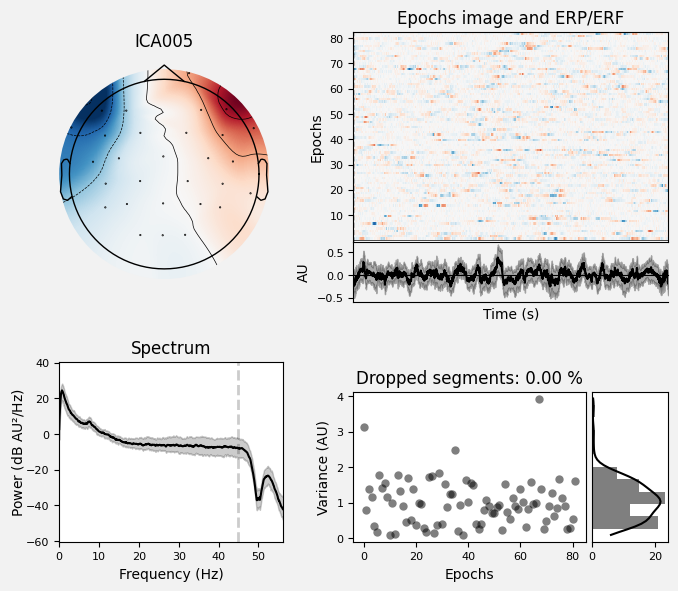

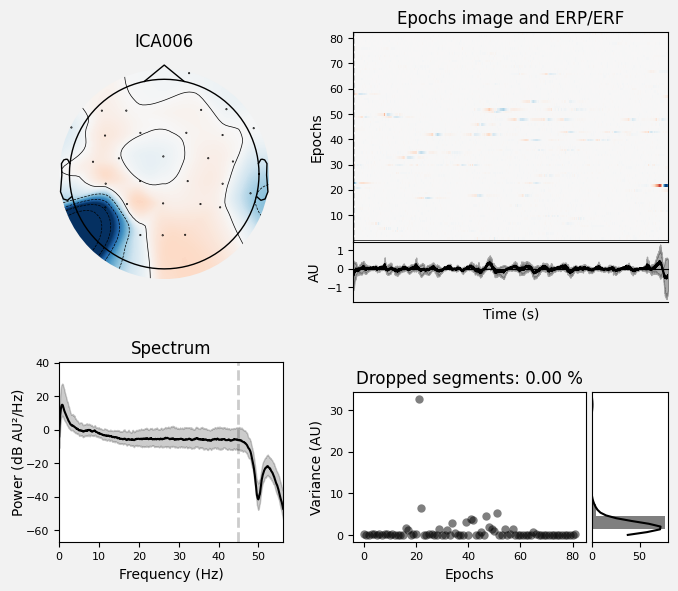

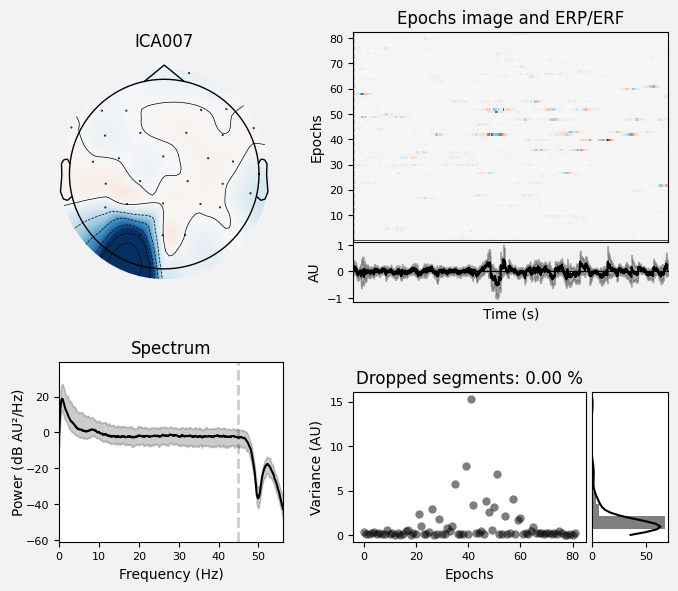

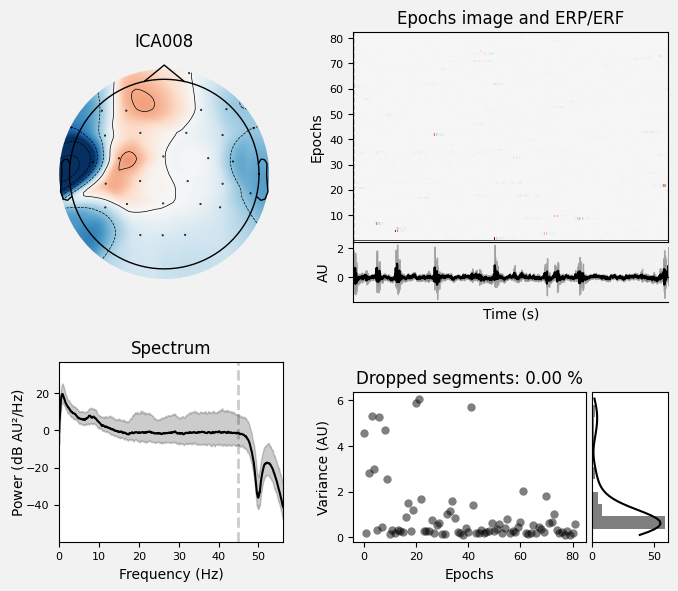

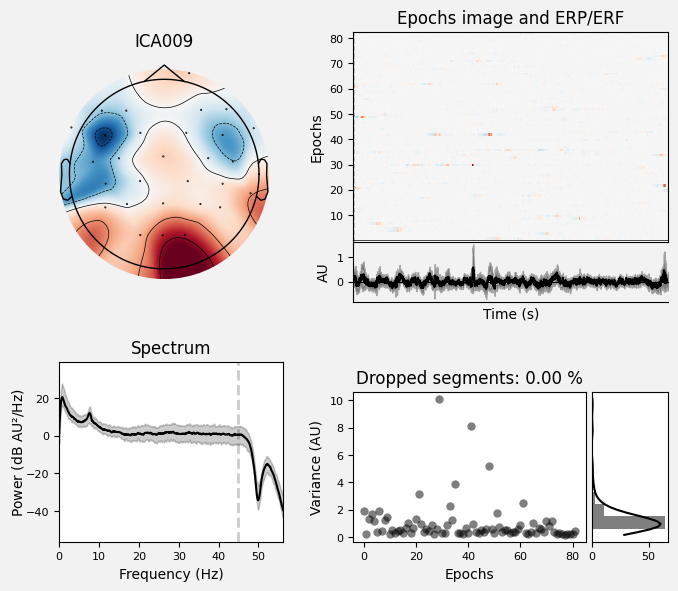

Creating RawArray with float64 data, n_channels=10, n_times=823001
    Range : 0 ... 823000 =      0.000 ...  1646.000 secs
Ready.


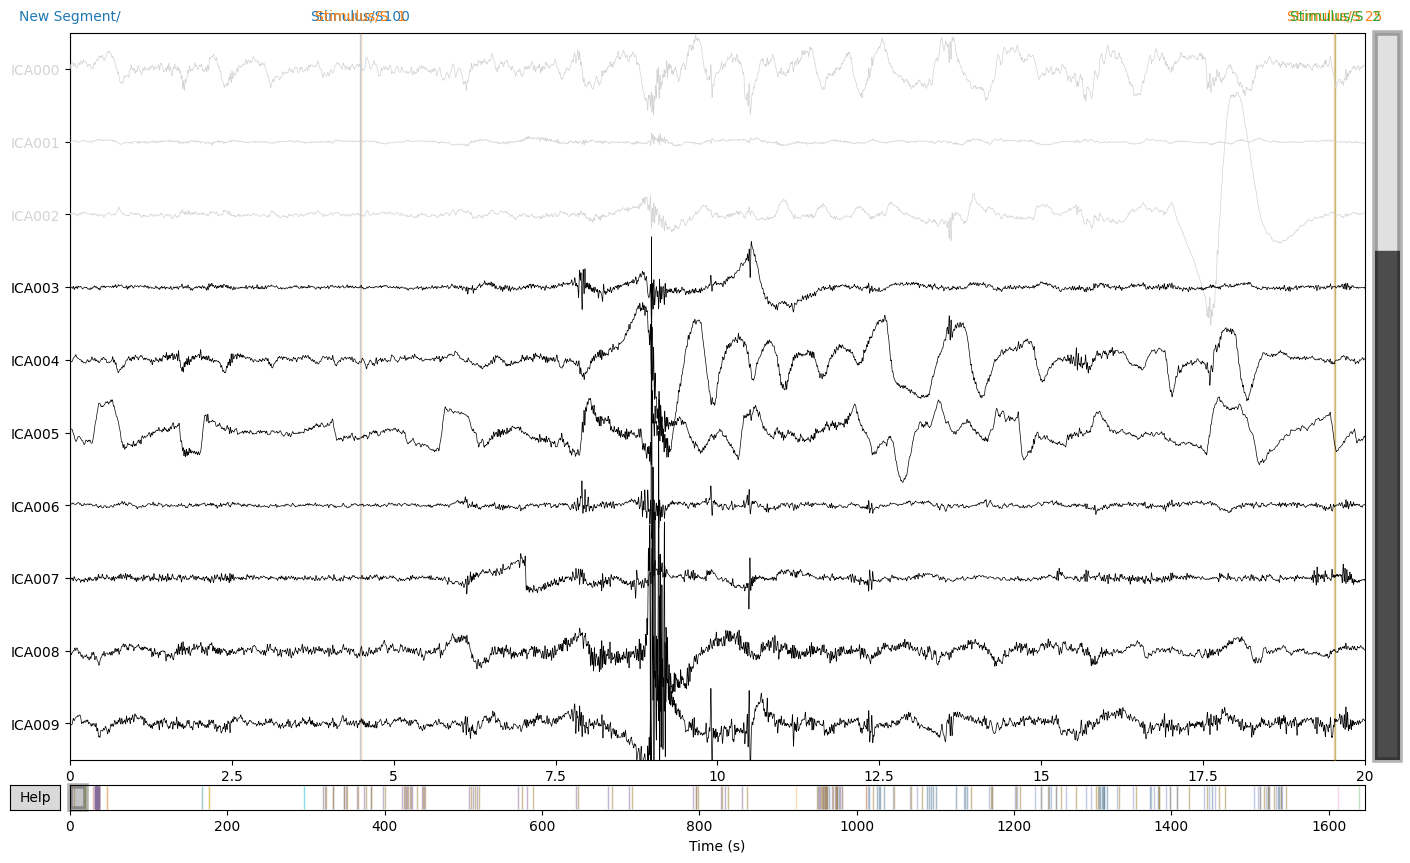

Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 29 PCA components


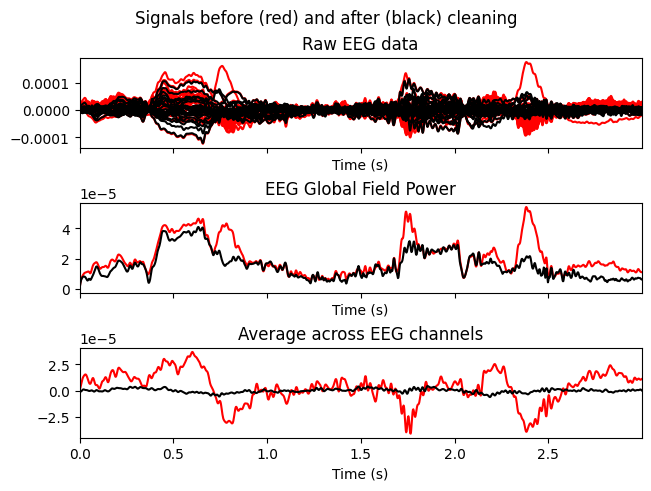

N components fitted: 10
Explained variance: [1.10763585e+01 5.56410043e+00 3.62380991e+00 2.25190806e+00
 1.80108458e+00 1.30266398e+00 7.36563513e-01 6.86034731e-01
 3.84710864e-01 3.54752073e-01 2.70634114e-01 1.91590223e-01
 1.47262179e-01 1.23178814e-01 8.71574919e-02 7.64637302e-02
 6.41715616e-02 5.35753066e-02 4.39330250e-02 3.13326053e-02
 2.53411991e-02 2.16335358e-02 1.86742338e-02 1.73594390e-02
 1.52395668e-02 1.34340451e-02 1.04252523e-02 6.07705162e-03
 2.44435080e-04]
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 29 PCA components


RecursionError: maximum recursion depth exceeded

In [15]:
# try for one patient for now 
pre_tic_epochs_p2_spont, random_epochs_p2_spont, bad_channels_p2_spont = full_pipeline_extract_pre_tic_epochs(patients[1], phase="spontaneous_phase", nb_random_epochs=50)

In [ ]:
# Extract pre-tic epochs for all patients in the spontaneous phase
#patient 1 - DS26
pre_tic_epochs_p1_spont, random_epochs_p1_spont, bad_channels_p1_spont = full_pipeline_extract_pre_tic_epochs(patients[0], phase="spontaneous_phase", nb_random_epochs=50)  
#patient 2 - BB28
pre_tic_epochs_p2_spont, random_epochs_p2_spont, bad_channels_p2_spont = full_pipeline_extract_pre_tic_epochs(patients[1], phase="spontaneous_phase", nb_random_epochs=50) 
#patient 3 - BC29
pre_tic_epochs_p3_spont, random_epochs_p3_spont, bad_channels_p3_spont = full_pipeline_extract_pre_tic_epochs(patients[2], phase="spontaneous_phase", nb_random_epochs=50)
#patient 4 - MM30
pre_tic_epochs_p4_spont, random_epochs_p4_spont, bad_channels_p4_spont = full_pipeline_extract_pre_tic_epochs(patients[3], phase="spontaneous_phase", nb_random_epochs=50)
#patient 5 - SC31
pre_tic_epochs_p5_spont, random_epochs_p5_spont, bad_channels_p5_spont = full_pipeline_extract_pre_tic_epochs(patients[4], phase="spontaneous_phase", nb_random_epochs=50)




In [ ]:
# Extract pre-tic epochs for all patients in the suppressed phase 
#patient 1
pre_tic_epochs_p1_sup ,pre_tic_epochs_p1_real_sup, random_epochs_p1_sup, bad_channels_p1_sup = full_pipeline_extract_pre_tic_epochs(patients[0], phase="suppressed_phase", nb_random_epochs=50) # no real tics in suppressed phase for patient 1, so this will return empty arrays 
#patient 2
pre_tic_epochs_p2_sup, pre_tic_epochs_p2_real_sup, random_epochs_p2_sup, bad_channels_p2_sup = full_pipeline_extract_pre_tic_epochs(patients[1], phase="suppressed_phase", nb_random_epochs=50) 
#patient 3
pre_tic_epochs_p3_sup, pre_tic_epochs_p3_real_sup, random_epochs_p3_sup, bad_channels_p3_sup = full_pipeline_extract_pre_tic_epochs(patients[2], phase="suppressed_phase", nb_random_epochs=50)
#patient 4
pre_tic_epochs_p4_sup, pre_tic_epochs_p4_real_sup, random_epochs_p4_sup, bad_channels_p4_sup = full_pipeline_extract_pre_tic_epochs(patients[3], phase="suppressed_phase", nb_random_epochs=50)
#patient 5
pre_tic_epochs_p5_sup, pre_tic_epochs_p5_real_sup, random_epochs_p5_sup, bad_channels_p5_sup = full_pipeline_extract_pre_tic_epochs(patients[4], phase="suppressed_phase", nb_random_epochs=50)




In [ ]:
# Extract pre-tic epochs for all patients in the imitated phase
#patient 1
pre_tic_epochs_p1_imit, pre_tic_epochs_p1_real_imit, random_epochs_p1_imit, bad_channels_p1_imit = full_pipeline_extract_pre_tic_epochs(patients[0], phase="imitated_phase", nb_random_epochs=50) 
#patient 2
pre_tic_epochs_p2_imit, pre_tic_epochs_p2_real_imit, random_epochs_p2_imit, bad_channels_p2_imit = full_pipeline_extract_pre_tic_epochs(patients[1], phase="imitated_phase", nb_random_epochs=50)
#patient 3
pre_tic_epochs_p3_imit, pre_tic_epochs_p3_real_imit, random_epochs_p3_imit, bad_channels_p3_imit = full_pipeline_extract_pre_tic_epochs(patients[2], phase="imitated_phase", nb_random_epochs=50)
#patient 4
pre_tic_epochs_p4_imit, pre_tic_epochs_p4_real_imit, random_epochs_p4_imit, bad_channels_p4_imit = full_pipeline_extract_pre_tic_epochs(patients[3], phase="imitated_phase", nb_random_epochs=50) # no real tics in imitated phase for patient 4, so this will return empty arrays 
#patient 5
pre_tic_epochs_p5_imit, pre_tic_epochs_p5_real_imit, random_epochs_p5_imit, bad_channels_p5_imit = full_pipeline_extract_pre_tic_epochs(patients[4], phase="imitated_phase", nb_random_epochs=50)


In [ ]:
# Each patient's data - spontaneous phase, imitated phase, suppressed phase
patients_data = {
    "DS26": {
        "spontaneous": (pre_tic_epochs_p1_spont, random_epochs_p1_spont, bad_channels_p1_spont),
        "suppressed": (pre_tic_epochs_p1_sup, pre_tic_epochs_p1_real_sup, random_epochs_p1_sup, bad_channels_p1_sup),
        "imitated": (pre_tic_epochs_p1_imit, pre_tic_epochs_p1_real_imit, random_epochs_p1_imit, bad_channels_p1_imit),
    },
    "BB28": {
        "spontaneous": (pre_tic_epochs_p2_spont, random_epochs_p2_spont, bad_channels_p2_spont),
        "suppressed": (pre_tic_epochs_p2_sup, pre_tic_epochs_p2_real_sup, random_epochs_p2_sup, bad_channels_p2_sup),
        "imitated": (pre_tic_epochs_p2_imit, pre_tic_epochs_p2_real_imit, random_epochs_p2_imit, bad_channels_p2_imit),
    },
    "BC29": {
        "spontaneous": (pre_tic_epochs_p3_spont, random_epochs_p3_spont, bad_channels_p3_spont),
        "suppressed": (pre_tic_epochs_p3_sup, pre_tic_epochs_p3_real_sup, random_epochs_p3_sup, bad_channels_p3_sup),
        "imitated": (pre_tic_epochs_p3_imit, pre_tic_epochs_p3_real_imit, random_epochs_p3_imit, bad_channels_p3_imit),
    },
    "MM30": {
        "spontaneous": (pre_tic_epochs_p4_spont, random_epochs_p4_spont, bad_channels_p4_spont),
        "suppressed": (pre_tic_epochs_p4_sup, pre_tic_epochs_p4_real_sup, random_epochs_p4_sup, bad_channels_p4_sup),
        "imitated": (pre_tic_epochs_p4_imit, pre_tic_epochs_p4_real_imit, random_epochs_p4_imit, bad_channels_p4_imit),
    },
    "SC31": {
        "spontaneous": (pre_tic_epochs_p5_spont, random_epochs_p5_spont, bad_channels_p5_spont),
        "suppressed": (pre_tic_epochs_p5_sup, pre_tic_epochs_p5_real_sup, random_epochs_p5_sup, bad_channels_p5_sup),
        "imitated": (pre_tic_epochs_p5_imit, pre_tic_epochs_p5_real_imit, random_epochs_p5_imit, bad_channels_p5_imit),
    },
}

## Raw Data Analysis

In [ ]:
def plot_raw_epochs_with_roi(epochs, patient, patient_id, phase_name, 
                                  save_folder='epochs_with_roi_colors', 
                                  scalings='auto'):
    import os
    import matplotlib.pyplot as plt
    import mne
    
    # Define ROIs and channels
    channels_to_use_32 = ["Cz", "C3", "C4", "Pz", "Fp1", "Fp2"]
    channels_to_use_64 = ["Cz", "FCz", "C3", "FC3", "CP3", "C4", "CP4", "FC4", "Pz", "CPz", "Fp1", "Fp2", "AF3", "AF4"]
    
    roi_lists_32 = {
        "midline_premotor": ["Cz"],
        "left_sensorimotor": ["C3"],
        "right_sensorimotor": ["C4"],
        "midline_posterior": ["Pz"],
        "midline_prefrontal": ["Fp1", "Fp2"]
    }
    roi_lists_64 = {
        "midline_premotor": ["Cz", "FCz"],
        "left_sensorimotor": ["C3", "FC3", "CP3"],
        "right_sensorimotor": ["C4", "CP4", "FC4"],
        "midline_posterior": ["Pz", "CPz"],
        "midline_prefrontal": ["Fp1", "Fp2", "AF3", "AF4"]
    }
    
    # ROI colors
    roi_colors = {
        "midline_premotor": "red",
        "left_sensorimotor": "blue",
        "right_sensorimotor": "green",
        "midline_posterior": "purple",
        "midline_prefrontal": "orange"
    }
    
    # Select channels and ROIs based on montage
    if patient["montage"] == "standard_1020":
        channels_to_use = channels_to_use_32
        roi_lists = roi_lists_32
    elif patient["montage"] == "standard_1005":
        channels_to_use = channels_to_use_64
        roi_lists = roi_lists_64
    else:
        raise ValueError(f"Unknown montage: {patient['montage']}")
    
    # Pick ROI channels
    available_channels = [ch for ch in channels_to_use if ch in epochs.ch_names]
    if not available_channels:
        print(f"No ROI channels available in epochs")
        return
    
    epochs_roi = epochs.copy().pick(available_channels)
    
    # Create channel-to-color mapping
    channel_colors = {}
    for roi_name, roi_channels in roi_lists.items():
        for ch in roi_channels:
            if ch in available_channels:
                channel_colors[ch] = roi_colors[roi_name]
    
    # Create save folder
    os.makedirs(save_folder, exist_ok=True)
    
    print(f"Plotting {len(epochs_roi)} epochs with ROI colors...")
    
    # Plot each epoch
    for idx in range(len(epochs_roi)):
        # Create the plot
        fig = epochs_roi[idx].plot(
            n_epochs=1,
            scalings=scalings,
            n_channels=len(available_channels),
            title=f'{patient_id} - Epoch {idx+1} - {phase_name}',
            show=False
        )
        
        # Color the channel labels by ROI
        # Get the axes with channel labels
        ax = fig.axes[0]
        
        # Iterate through y-tick labels (channel names) and color them
        for label in ax.get_yticklabels():
            ch_name = label.get_text()
            if ch_name in channel_colors:
                label.set_color(channel_colors[ch_name])
                label.set_weight('bold')
        
        # Add legend for ROI colors
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, label=roi_name) 
                          for roi_name, color in roi_colors.items()]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
        
        # Save figure
        filename = f'{patient_id}_epoch_{idx+1}_{phase_name}_ROI_colored.png'
        fig.savefig(os.path.join(save_folder, filename), dpi=150, bbox_inches='tight')
        print(f"  Saved: {filename}")
        plt.close(fig)
    
    print(f"All epochs saved to {save_folder}")



In [ ]:
# Loop through all patients and all phases
for patient_id, patient_phases in patients_data.items():
    # Get corresponding patient dict from patients list
    patient_idx = list(patients_data.keys()).index(patient_id)
    patient = patients[patient_idx]
    
    print(f"\n{'='*60}")
    print(f"Processing patient: {patient_id}")
    print(f"{'='*60}")
    
    for phase_name, phase_data in patient_phases.items():
        print(f"\n--- Phase: {phase_name} ---")
        
        # Unpack based on phase type
        if phase_name == 'spontaneous':
            pre_tic_epochs, random_epochs, bad_channels = phase_data
            epochs_dict = {}
            if pre_tic_epochs is not None and len(pre_tic_epochs) > 0:
                epochs_dict['pre_tic'] = pre_tic_epochs
            if random_epochs is not None and len(random_epochs) > 0:
                epochs_dict['random'] = random_epochs
        
        else:  # imitated or suppressed
            pre_tic_cat1, pre_tic_cat2, random_epochs, bad_channels = phase_data
            category_name = phase_name  # 'imitated' or 'suppressed'
            epochs_dict = {}
            
            if pre_tic_cat1 is not None and len(pre_tic_cat1) > 0:
                epochs_dict[category_name] = pre_tic_cat1
            if pre_tic_cat2 is not None and len(pre_tic_cat2) > 0:
                epochs_dict['real'] = pre_tic_cat2
            if random_epochs is not None and len(random_epochs) > 0:
                epochs_dict['random'] = random_epochs
        
        # Plot each category
        for category_name, epochs in epochs_dict.items():
            print(f"  Plotting {category_name}: {len(epochs)} epochs")
            
            plot_raw_epochs_with_roi(
                epochs=epochs,
                patient=patient,
                patient_id=patient_id,
                phase_name=f'{phase_name}_{category_name}',
                save_folder=f'raw_epochs_ICA/{patient_id}/{phase_name}/{category_name}'
            )

## Time-Frequency Analysis

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import mne

from mne import Epochs, create_info
from mne.io import RawArray
from mne.time_frequency import AverageTFRArray, EpochsTFRArray, tfr_morlet

print(__doc__)

## Analysis Per Event

Each event is plotted seperately after z-score normalization, 5 selected ROI are chosen for plotting

In [ ]:
def plot_tfr_per_epoch_per_roi(patient, epochs_dict, random_epochs, patient_id, phase_type,
                                event_key='urge', tmin=-1, tmax=0.2,
                                save_folder=None, normalization='zscore'):

    import matplotlib.pyplot as plt
    import math
    import numpy as np
    import os

    if save_folder:
        os.makedirs(save_folder, exist_ok=True)

    all_tfr_by_condition = {}
    freqs, times = None, None

    for condition_name, epochs in epochs_dict.items():
        if epochs is None or len(epochs) == 0:
            print(f"  SKIPPING {condition_name} - empty epoch array")
            continue

        epochs_event = epochs[event_key]
        n_epochs = len(epochs_event)
        all_tfr_by_condition[condition_name] = []
    # compute TFR for each epoch and ROI
        for idx in range(n_epochs):
            roi_tfr, freqs, times, _ = tfr_per_ROI_normalized(
                patient,
                epochs_event[idx],
                random_epochs,
                epoch_type='pre_tic',
                freqs=np.arange(1.0, 40.0, 2.0),
                bad_channels=[],
                normalization=normalization
            )
            all_tfr_by_condition[condition_name].append(roi_tfr)

   # Compute vmin/vmax based on 98th percentile across all conditions, epochs, and ROIs
    all_values = np.concatenate([
        data.flatten()
        for condition_tfrs in all_tfr_by_condition.values()  
        for roi_tfr in condition_tfrs                       
        for data in roi_tfr.values()                       
    ])

    abs_max = np.percentile(np.abs(all_values), 98)
    vmin, vmax = -abs_max, abs_max
    print(f"\nColor scale (98th percentile across all conditions): vmin={vmin:.2f}, vmax={vmax:.2f}")

    for condition_name, condition_tfrs in all_tfr_by_condition.items():
        print(f"\nPlotting condition: {condition_name}")

        for idx, roi_tfr in enumerate(condition_tfrs):
            fig = plot_trf_roi(
                roi_tfr, freqs, times,
                n=1, vmin=vmin, vmax=vmax,
                epoch_type='pre_tic'
            )
            fig.suptitle(f"{patient_id} - {phase_type} - {condition_name} - Epoch {idx+1}",
                        fontsize=14)

            if save_folder:
                filename = f'{patient_id}_{phase_type}_{condition_name}_epoch_{idx+1}.png'
                fig.savefig(os.path.join(save_folder, filename), dpi=150, bbox_inches='tight')
                print(f"  Saved: {filename}")
                plt.close(fig)
            else:
                plt.show()


## One patient - TFR per event

In [ ]:
def plot_tfr_per_epoch_per_roi(patient, epochs, random_epochs, patient_id, phase_type,
                                event_key='urge', tmin=-1, tmax=0.2,
                                save_folder=None, normalization='zscore'):

    import matplotlib.pyplot as plt
    import math
    import numpy as np
    import os

    if save_folder:
        os.makedirs(save_folder, exist_ok=True)
    
    all_tfr = []
    n_epochs = len(epochs[event_key])

    # compute TFR for each epoch and ROI
    for idx in range(n_epochs):
        epoch = epochs[event_key][idx]
        roi_tfr, freqs, times, _ = tfr_per_ROI_normalized(
            patient,
            epoch ,
            random_epochs,
            epoch_type='pre_tic',
            freqs=np.arange(1.0, 40.0, 2.0),
            bad_channels=[],
            normalization=normalization
        )
        all_tfr.append(roi_tfr)

   # Compute vmin/vmax based on 98th percentile across all conditions, epochs, and ROIs
    all_values = np.concatenate([
        data.flatten()   
        for roi_tfr in all_tfr                  
        for data in roi_tfr.values()                    
    ])

    abs_max = np.percentile(np.abs(all_values), 98)
    vmin, vmax = -abs_max, abs_max
    print(f"\nColor scale (98th percentile across all conditions): vmin={vmin:.2f}, vmax={vmax:.2f}")

    for idx, roi_tfr in enumerate(all_tfr):
        fig = plot_trf_roi(
            roi_tfr, freqs, times,
            n=1, vmin=vmin, vmax=vmax,
            epoch_type='pre_tic'
        )
        fig.suptitle(f"{patient_id} - {phase_type}  - Epoch {idx+1}",
                    fontsize=14)

        if save_folder:
            filename = f'{patient_id}_{phase_type}_epoch_{idx+1}.png'
            fig.savefig(os.path.join(save_folder, filename), dpi=150, bbox_inches='tight')
            print(f"  Saved: {filename}")
            plt.close(fig)
        else:
            plt.show()


In [ ]:
# Example usage for one patient and one phase
patient_id = "DS26"
phase = "spontaneous"
plot_tfr_per_epoch_per_roi(
    patient=patients[0], 
    epochs=pre_tic_epochs_p1_spont, 
    random_epochs=random_epochs_p1_spont, 
    patient_id=patient_id, 
    phase_type=phase,
    save_folder="tfr_ICA_autoreject/DS26/spontaneous_phase",
    normalization='zscore'
)


In [ ]:
for patient_id, patient, patient_phases in zip(patients_data.keys(), patients, patients_data.values()):
    
    for phase_name, phase_data in patient_phases.items():
        print(f"\n--- Phase: {phase_name} ---")

        if phase_name == 'spontaneous':
            pre_tic_epochs, random_epochs, bad_channels = phase_data
            epochs_dict = {'spontaneous': pre_tic_epochs}
        
        else:  
            pre_tic_cat1, pre_tic_cat2, random_epochs, bad_channels = phase_data
            category_name = 'imitated' if phase_name == 'imitated' else 'suppressed'
            
            epochs_dict = {}
            if pre_tic_cat1 is not None:
                epochs_dict[category_name] = pre_tic_cat1
            else:
                print(f"  SKIPPING {category_name} - empty")
            
            if pre_tic_cat2 is not None:
                epochs_dict['real'] = pre_tic_cat2
            else:
                print(f"  SKIPPING real - empty")
            
            if not epochs_dict:
                print(f"  SKIPPING {phase_name} entirely - all empty")
                continue
        
        # Plot
        plot_tfr_per_epoch_per_roi(
            patient=patient,
            epochs_dict=epochs_dict,
            random_epochs=random_epochs,
            patient_id=patient_id,
            phase_type=phase_name,
            save_folder=f'tfr_ICA_autoreject/{patient_id}/{phase_name}'
        )

## Analysis Averaged Across Epochs 

In [ ]:
def plot_tfr_averaged_all_phases(patient, patient_id, patient_data, save_folder='tfr_results_all_phases'):
    """
    Plot averaged TFR for all phases of one patient using preloaded data.
    Skips empty epoch arrays (None).
    vmin/vmax based on 98th percentile across all phases and conditions.
    """
    import os
    import matplotlib.pyplot as plt
    import numpy as np

    os.makedirs(save_folder, exist_ok=True)

    # compute all TFRs first                                      
    all_roi_tfr = {}  

    for phase_name, phase_data in patient_data.items():
        print(f"\n--- Phase: {phase_name} ---")

        # Unpack based on phase type
        if phase_name == 'spontaneous':
            pre_tic_epochs, random_epochs, bad_channels = phase_data
            
            if pre_tic_epochs is None or len(pre_tic_epochs) == 0:
                print(f"  SKIPPING {phase_name} - empty epoch array")
                continue
            
            epochs_dict = {'spontaneous': pre_tic_epochs}

        else:  # imitated or suppressed
            pre_tic_cat1, pre_tic_cat2, random_epochs, bad_channels = phase_data
            category_name = phase_name  # 'imitated' or 'suppressed'
            epochs_dict = {}

            if pre_tic_cat1 is not None and len(pre_tic_cat1) > 0:
                epochs_dict[category_name] = pre_tic_cat1
            else:
                print(f"  SKIPPING {category_name} - empty epoch array")

            if pre_tic_cat2 is not None and len(pre_tic_cat2) > 0:
                epochs_dict['real'] = pre_tic_cat2
            else:
                print(f"  SKIPPING real - empty epoch array")

            if not epochs_dict:
                print(f"  SKIPPING {phase_name} entirely - all epoch arrays empty")
                continue

        # Compute TFR for each category
        for category_name, epochs in epochs_dict.items():
            print(f"  Computing TFR for {category_name}: {len(epochs)} epochs")

            roi_tfr, freqs, times, n_epochs = tfr_per_ROI_normalized(
                patient,
                epochs,
                epoch_type='pre_tic',
                random_epochs=random_epochs,
                bad_channels=bad_channels,
                normalization='zscore'
            )

            all_roi_tfr[(phase_name, category_name)] = (roi_tfr, freqs, times, n_epochs)

    if not all_roi_tfr:
        print("No TFR results computed - skipping")
        return

    # compute vmin/vmax across ALL phases and conditions          
    all_values = np.concatenate([
        data.flatten()
        for roi_tfr, freqs, times, n_epochs in all_roi_tfr.values()
        for data in roi_tfr.values()
    ])

    abs_max = np.percentile(np.abs(all_values), 98)
    vmin, vmax = -abs_max, abs_max
    print(f"\nColor scale (98th percentile across all phases): vmin={vmin:.2f}, vmax={vmax:.2f}")

    #  plot all TFRs with consistent color scale                   
    for (phase_name, category_name), (roi_tfr, freqs, times, n_epochs) in all_roi_tfr.items():
        fig = plot_trf_roi(roi_tfr, freqs, times, n_epochs, epoch_type='pre_tic', vmin=vmin, vmax=vmax)

        filename = f"{patient_id}_{phase_name}_{category_name}_TFR_n{n_epochs}.png"
        fig.savefig(
            os.path.join(save_folder, filename),
            dpi=300,
            bbox_inches="tight"
        )
        print(f"  Saved: {filename}")
        plt.close(fig)




## Per one patient - across all roi

In [ ]:
def plot_tfr_averaged_all_phases(patient, patient_id, phase_name, epochs, random_epochs, bad_channels, save_folder='tfr_results_all_phases'):
    """
    Plot averaged TFR for all phases of one patient using preloaded data.
    Skips empty epoch arrays (None).
    vmin/vmax based on 98th percentile across all phases and conditions.
    """
    import os
    import matplotlib.pyplot as plt
    import numpy as np

    os.makedirs(save_folder, exist_ok=True)

    # compute all TFRs first                                      
    all_roi_tfr = []

    roi_tfr, freqs, times, n_epochs = tfr_per_ROI_normalized(
        patient,
        epochs,
        epoch_type='pre_tic',
        random_epochs=random_epochs,
        bad_channels=bad_channels,
        normalization='zscore'
    )

    all_roi_tfr.append(roi_tfr)


    # compute vmin/vmax across ALL phases and conditions          
    all_values = np.concatenate([data.flatten() for data in roi_tfr.values()])
    abs_max = np.percentile(np.abs(all_values), 98)
    vmin, vmax = -abs_max, abs_max
    print(f"Color scale: vmin={vmin:.2f}, vmax={vmax:.2f}")
    
    #  plot all TFRs with consistent color scale                   
    fig = plot_trf_roi(roi_tfr, freqs, times, n_epochs, epoch_type='pre_tic', vmin=vmin, vmax=vmax)

    filename = f"{patient_id}_{phase_name}_TFR_n{n_epochs}.png"
    fig.savefig(
        os.path.join(save_folder, filename),
        dpi=300,
        bbox_inches="tight"
    )
    print(f"  Saved: {filename}")
    plt.close(fig)




In [ ]:
# Single patient, all phases
plot_tfr_averaged_all_phases(
    patient=patients[0],
    patient_id='DS26',
    phase_name='spontaneous',
    epochs=pre_tic_epochs_p1_spont,
    random_epochs=random_epochs_p1_spont,
    bad_channels=bad_channels_p1_spont,
    save_folder='tfr_ICA_autoreject/DS26/spontaneous_phase_all_epochs'
)

In [ ]:
# Loop through all patients
patient_id = ["DS26", "BB28", "BC29", "MM30", "SC31"]
# ========== Loop through all patients using preloaded patients_data ==========
for patient_id, patient_phases in patients_data.items():
    # Get corresponding patient dict from patients list
    patient_idx = list(patients_data.keys()).index(patient_id)
    
    plot_tfr_averaged_all_phases(
        patient=patients[patient_idx],
        patient_id=patient_id,
        patient_data=patient_phases,
        save_folder=f'tfr_results_all_phases_ICA/{patient_id}'
    )